In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

print("Phiên bản TensorFlow đang dùng:", tf.__version__)

Phiên bản TensorFlow đang dùng: 2.20.0


In [3]:
BATCH_SIZE = 32
IMG_SIZE = (256, 256)
EPOCHS_PHASE_1 = 15
EPOCHS_PHASE_2 = 15

In [4]:
TRAIN_DIR = 'output/train' 
VAL_DIR = 'output/val'

In [5]:
print("Đang tải tập dữ liệu Huấn luyện (Training)...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Đang tải tập dữ liệu Huấn luyện (Training)...
Found 1721 files belonging to 3 classes.


In [6]:
print("Đang tải tập dữ liệu Kiểm tra (Validation)...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Đang tải tập dữ liệu Kiểm tra (Validation)...
Found 215 files belonging to 3 classes.


In [7]:
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Tìm thấy {NUM_CLASSES} loại bệnh: {class_names}")

Tìm thấy 3 loại bệnh: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

# Định nghĩa các phép biến đổi ảnh
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# Chỉ áp dụng Augmentation cho tập Train
train_dataset = train_dataset.cache()
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

# Tập Validation giữ nguyên, chỉ đẩy vào Cache cho tốc độ nhanh
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Đã thiết lập xong luồng dữ liệu!")

Đã thiết lập xong luồng dữ liệu!


In [9]:
# Tải "Phân thân" của MobileNetV2 (Khóa lại không cho học)
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False 

# Bắt đầu nối cáp
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

# CHUẨN HÓA: Đưa pixel từ [0,255] về [-1, 1] (Thay cho hàm preprocess_input hay gây lỗi)
x = layers.Rescaling(1./127.5, offset=-1)(inputs)

# Đi qua MobileNetV2
x = base_model(x, training=False)

# Rút trích và phân loại
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Đóng gói
model = tf.keras.Model(inputs, outputs)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\HUY\AppData\Local\Temp\ipykernel_27808\1813277394.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Cài đặt tự động dừng nếu mô hình không học thêm được gì
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("🚀 BẮT ĐẦU GIAI ĐOẠN 1: Học đặc trưng phân loại...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_PHASE_1,
    callbacks=[early_stop]
)

🚀 BẮT ĐẦU GIAI ĐOẠN 1: Học đặc trưng phân loại...
Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 539ms/step - accuracy: 0.7804 - loss: 0.5405 - val_accuracy: 0.8977 - val_loss: 0.2698
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 473ms/step - accuracy: 0.9274 - loss: 0.2374 - val_accuracy: 0.9395 - val_loss: 0.1671
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 487ms/step - accuracy: 0.9448 - loss: 0.1616 - val_accuracy: 0.9581 - val_loss: 0.1358
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 471ms/step - accuracy: 0.9570 - loss: 0.1312 - val_accuracy: 0.9628 - val_loss: 0.1135
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 463ms/step - accuracy: 0.9605 - loss: 0.1146 - val_accuracy: 0.9628 - val_loss: 0.1054
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 476ms/step - accuracy: 0.9634 - loss: 0.1051 - val_accuracy: 0.9674 - val_loss: 0.0963
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 501ms/step - accuracy: 0.9657 - loss: 0.0976 - val_accuracy: 0.9721 - val_loss: 0.0890
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 497ms

In [11]:
print("🚀 BẮT ĐẦU GIAI ĐOẠN 2: Tinh chỉnh sâu (Fine Tuning)...")

# Mở khóa toàn bộ
base_model.trainable = True

# Nhưng khóa lại 100 lớp đầu tiên (chỉ dạy khoảng 50 lớp cuối)
for layer in base_model.layers[:100]:
    layer.trainable = False

# Bắt buộc Learning Rate siêu nhỏ để không phá nát trọng số
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_PHASE_2,
    callbacks=[early_stop]
)

🚀 BẮT ĐẦU GIAI ĐOẠN 2: Tinh chỉnh sâu (Fine Tuning)...
Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 734ms/step - accuracy: 0.9576 - loss: 0.1073 - val_accuracy: 0.9256 - val_loss: 0.1696
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 719ms/step - accuracy: 0.9837 - loss: 0.0497 - val_accuracy: 0.9767 - val_loss: 0.0663
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 733ms/step - accuracy: 0.9843 - loss: 0.0398 - val_accuracy: 0.9674 - val_loss: 0.1112
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 724ms/step - accuracy: 0.9884 - loss: 0.0339 - val_accuracy: 0.9674 - val_loss: 0.1309


In [12]:
MODEL_NAME = "nhanDienLaSauBenh.h5"
model.save(MODEL_NAME)
print(f"\n✅ ĐÃ LƯU MÔ HÌNH THÀNH CÔNG: {MODEL_NAME}")
print(f"\n⚠️ COPY DÒNG NÀY VÀO FILE app.py:")
print(f"CLASS_NAMES = {class_names}")


✅ ĐÃ LƯU MÔ HÌNH THÀNH CÔNG: nhanDienLaSauBenh.h5

⚠️ COPY DÒNG NÀY VÀO FILE app.py:
CLASS_NAMES = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


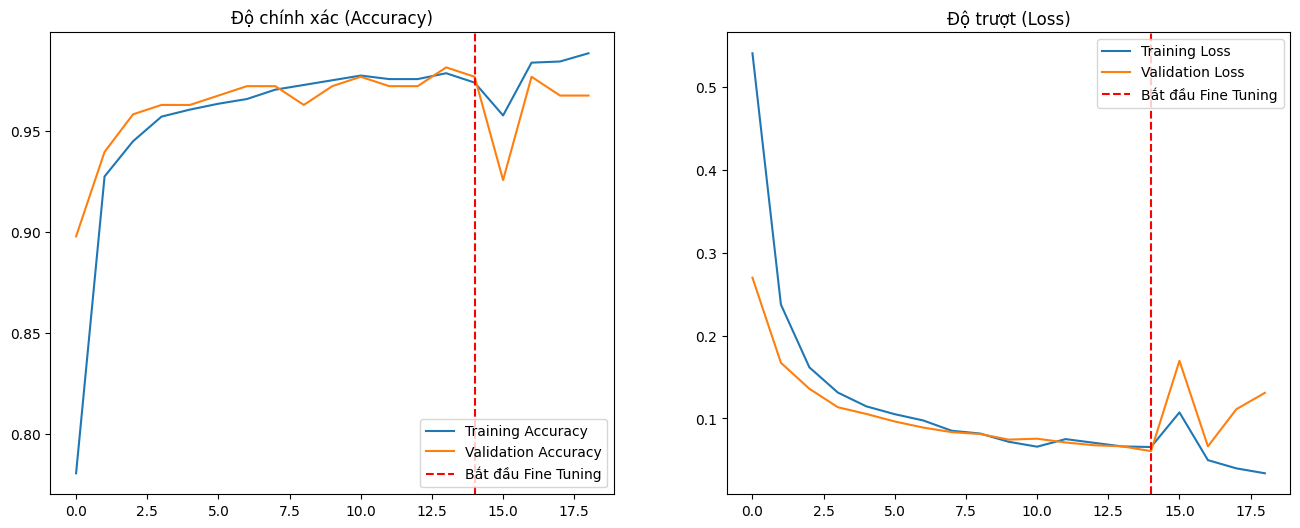

In [13]:
# Ghép lịch sử 2 giai đoạn lại với nhau
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Thời điểm chuyển giao giữa 2 giai đoạn
initial_epochs = len(history.history['accuracy'])

plt.figure(figsize=(16, 6))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=initial_epochs-1, color='r', linestyle='--', label='Bắt đầu Fine Tuning')
plt.legend(loc='lower right')
plt.title('Độ chính xác (Accuracy)')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=initial_epochs-1, color='r', linestyle='--', label='Bắt đầu Fine Tuning')
plt.legend(loc='upper right')
plt.title('Độ trượt (Loss)')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


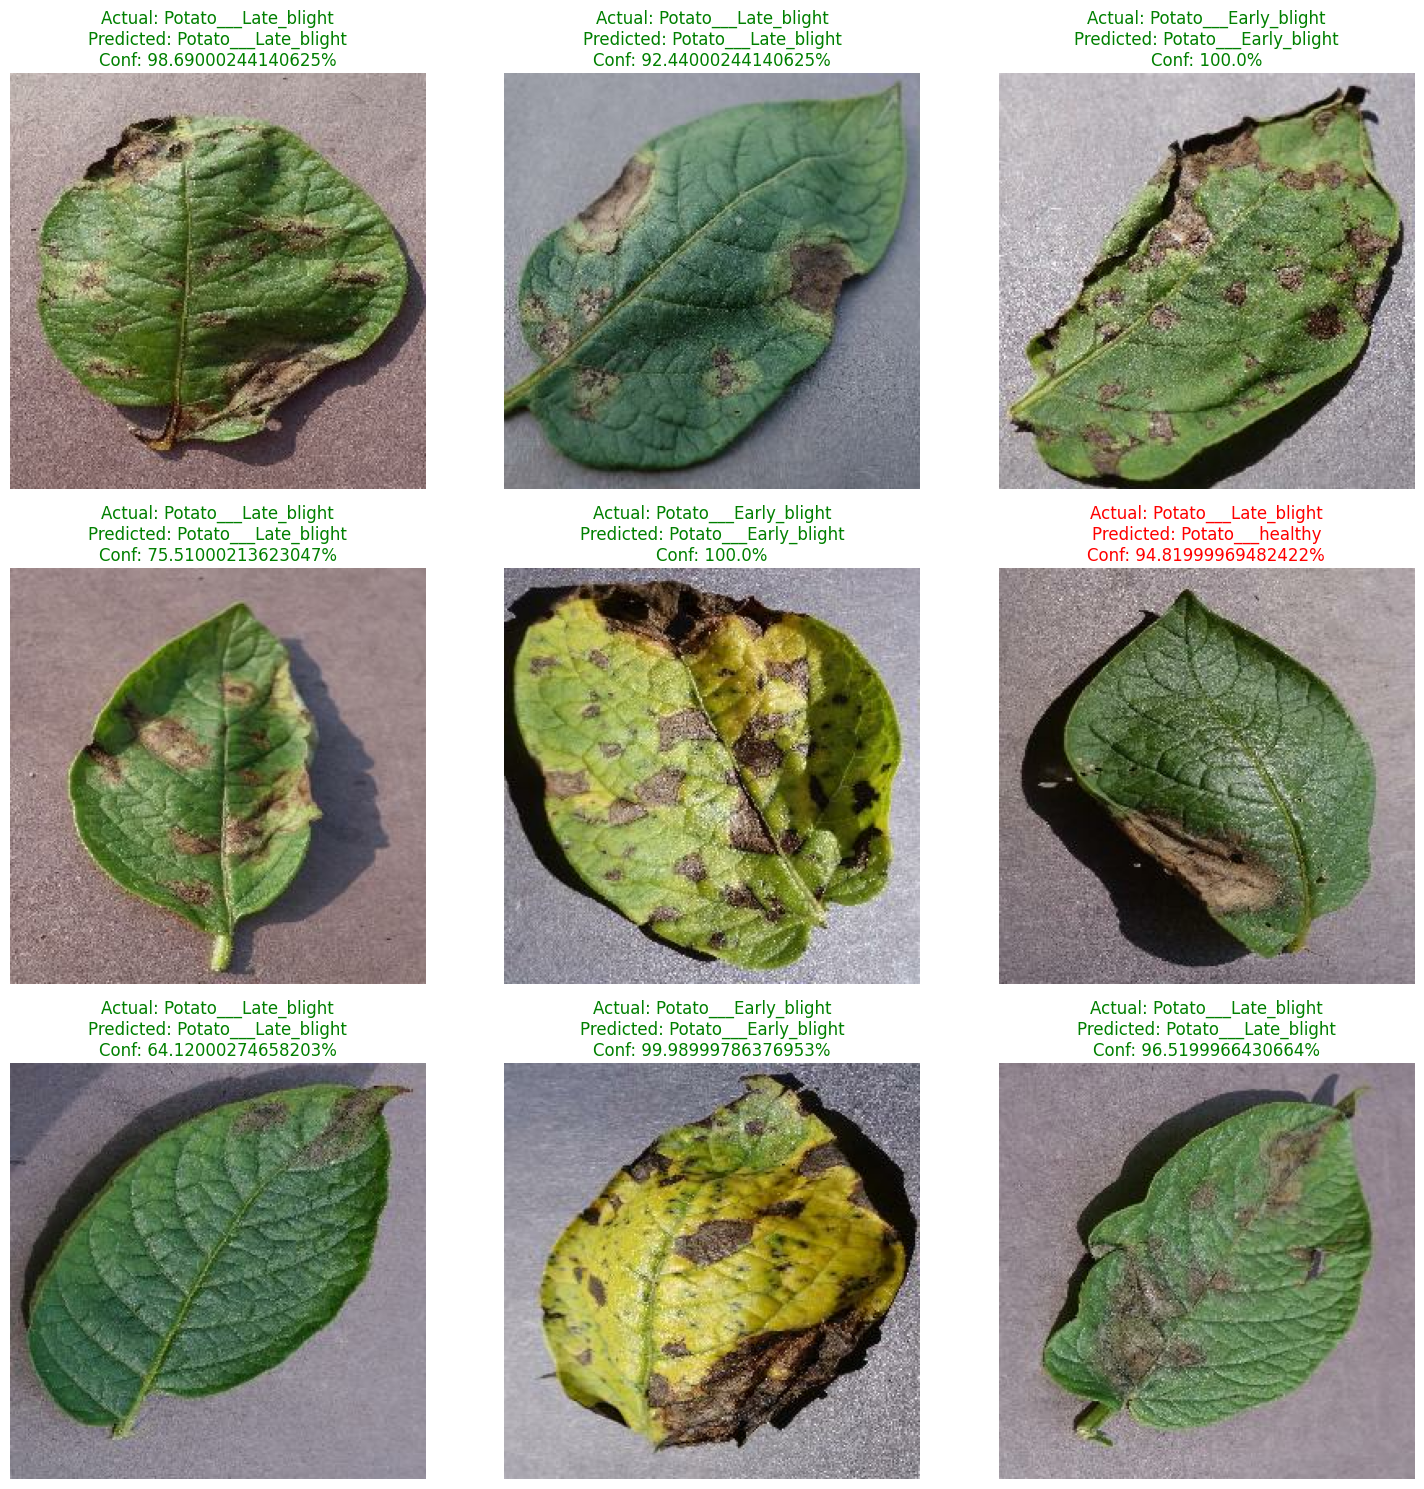

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Thiết kế khung ảnh 3x3
plt.figure(figsize=(15, 15))

# Lấy 1 batch từ tập test (hoặc validation_dataset của em)
for images, labels in val_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # 1. Hiển thị ảnh: Ép kiểu về uint8 để matplotlib hiểu đúng dải màu 0-255
        img_display = images[i].numpy().astype("uint8")
        plt.imshow(img_display)
        
        # 2. Dự đoán: Thêm chiều batch (1, 256, 256, 3) vì model không nhận ảnh đơn lẻ
        img_batch = np.expand_dims(images[i].numpy(), 0)
        predictions = model.predict(img_batch)
        
        # 3. Lấy kết quả
        predicted_class = class_names[np.argmax(predictions[0])]
        confidence = round(100 * (np.max(predictions[0])), 2)
        actual_class = class_names[labels[i]] 
        
        # 4. Hiển thị tiêu đề (Màu xanh nếu đúng, màu đỏ nếu sai cho dễ nhìn)
        title_color = "green" if predicted_class == actual_class else "red"
        
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConf: {confidence}%", 
                  color=title_color, fontsize=12)
        
        plt.axis("off")

plt.tight_layout()
plt.show()